In [87]:
import glob
import os
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
from IPython.display import display

import ldparser
from ldparser import ldData

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import silhouette_score

In [88]:
ld_data = glob.glob("raw_data/*.ld")
print(f"[Info] {len(ld_data)} Telemetriedateien im Ordner gefunden.")

# Mapping der relevanten Kanäle zu den Spaltennamen im DataFrame
channel_tuple_mapping = {
    'Suspension Travel FL': 's_damperFL',
    'Brake Bias': 'percent_brake_balance',
    'Brake Temp FL': 't_brakeFL',
    'Wheel Angular Speed FL': 'v_tyreFL'
}

[Info] 5 Telemetriedateien im Ordner gefunden.


In [89]:
master_feature_liste = []

for ld_file in ld_data:
    timestamp_in_seconds = []
    ldx_file = ld_file.replace('.ld', '.ldx')

    # LDX-Datei einlesen und Zeitstempel der Beacons extrahieren
    try: 
        ldx_file_tree = ET.parse(ldx_file)
        ldx_file_root = ldx_file_tree.getroot()

        for beacon in ldx_file_root.findall('.//MarkerGroup[@Name="Beacons"]/Marker'):
            time_node = beacon.get('Time')

            if time_node is not None:
                time_node_in_seconds = float(time_node) / 1000000.0
                timestamp_in_seconds.append(time_node_in_seconds)
    except Exception as e:
        print(f"\n{e}")

    # LD-Datei einlesen und relevante Kanäle extrahieren
    telemetry_tuple = ldData.fromfile(ld_file)
    channel_data = {}
    for ld_name, htf_name in channel_tuple_mapping.items():
        
        if ld_name in telemetry_tuple:
            channel_object = telemetry_tuple[ld_name]
            channel_data[htf_name] = pd.Series(data=channel_object.data, index=np.arange(len(channel_object.data)) / getattr(channel_object, 'freq'))

            df_telemetry = pd.DataFrame(channel_data)

        else:
            print(f"\n{e}")
    

    for i in range(len(timestamp_in_seconds) - 1):
        # Zeit der Fahrer pro Rundenabschnitt extrahieren
        start_time = timestamp_in_seconds[i]
        end_time = timestamp_in_seconds[i + 1]
        
        curve_data = df_telemetry[(df_telemetry.index >= start_time) & (df_telemetry.index < end_time)]
        if curve_data.empty:
            continue

        # Fahrer-ID aus dem Dateinamen extrahieren
        file_name = os.path.basename(ld_file)
        data_name_parted = file_name.split('_&_')
        
        if len(data_name_parted) >= 3:
            driver_id = data_name_parted[2]
        else:
            driver_id = file_name
            
        feature = {
            'Fahrer_ID': driver_id,
            'Segment_Nummer': i + 1,
            's_damperFL_max': curve_data['s_damperFL'].max(),           
            's_damperFL_var': curve_data['s_damperFL'].var(),           
            'percent_brake_balance_mean': curve_data['percent_brake_balance'].mean(), 
            't_brakeFL_max': curve_data['t_brakeFL'].max(),             
            'v_tyreFL_mean': curve_data['v_tyreFL'].mean()
        }
        master_feature_liste.append(feature)

df_master_ml = pd.DataFrame(master_feature_liste)
display(df_master_ml)
    

,Fahrer_ID,Segment_Nummer,s_damperFL_max,s_damperFL_var,percent_brake_balance_mean,t_brakeFL_max,v_tyreFL_mean
0,THTH312,1,114.614000,125.730297,54.000002,26.0,78.728081
1,THTH312,2,118.406000,99.654252,54.000002,26.0,65.150724
2,THTH312,3,114.294000,106.110113,54.000002,26.0,74.061532
3,THTH312,4,113.084000,125.396153,54.000002,26.0,78.693141
4,THTH312,5,113.676000,121.847042,54.000002,26.0,73.625121
5,THTH312,6,106.464000,129.068844,54.000002,26.0,80.377248
6,ALAD201,1,93.808333,53.107145,54.000002,26.0,65.151012
7,ALAD201,2,105.761667,85.369808,54.000002,26.0,68.343661
8,ALAD201,3,108.960000,92.803041,54.000002,26.0,66.787381
9,ALAD201,4,83.383333,76.818705,54.000002,26.0,79.824516


In [90]:
import pandas as pd
import glob
import os

csv_data = glob.glob('processed_data/*.csv')
all_driver_data = []

for data_file in csv_data:
    dateiname = os.path.basename(data_file)
    probanden_id = dateiname.split('_')[0] 
    
    df_temp = pd.read_csv(data_file, skiprows=7)
    
    df_temp['Fahrer_ID'] = probanden_id
    
    all_driver_data.append(df_temp)

# Alle Tabellen zu einem riesigen Master-DataFrame zusammenkleben
df_master_ml_real = pd.concat(all_driver_data, ignore_index=True)

print(f"[OK] {len(csv_data)} Probanden-Dateien erfolgreich geladen!")
print(f"-> Gefundene IDs: {df_master_ml_real['Fahrer_ID'].unique()}")

[OK] 10 Probanden-Dateien erfolgreich geladen!
-> Gefundene IDs: <StringArray>
['TOINZ27000', 'INBWZ11002', 'MAAKZ19001', 'CHIPZ26000', 'PASZZ20000',
 'MAMCZ06001']
Length: 6, dtype: str


 -> Cluster 0 wird offiziell erkannt als: SOMD122
 -> Cluster 1 wird offiziell erkannt als: RINE150
 -> Cluster 2 wird offiziell erkannt als: THTH312
 -> Cluster 3 wird offiziell erkannt als: ALAD201
 -> Cluster 4 wird offiziell erkannt als: NIMB230


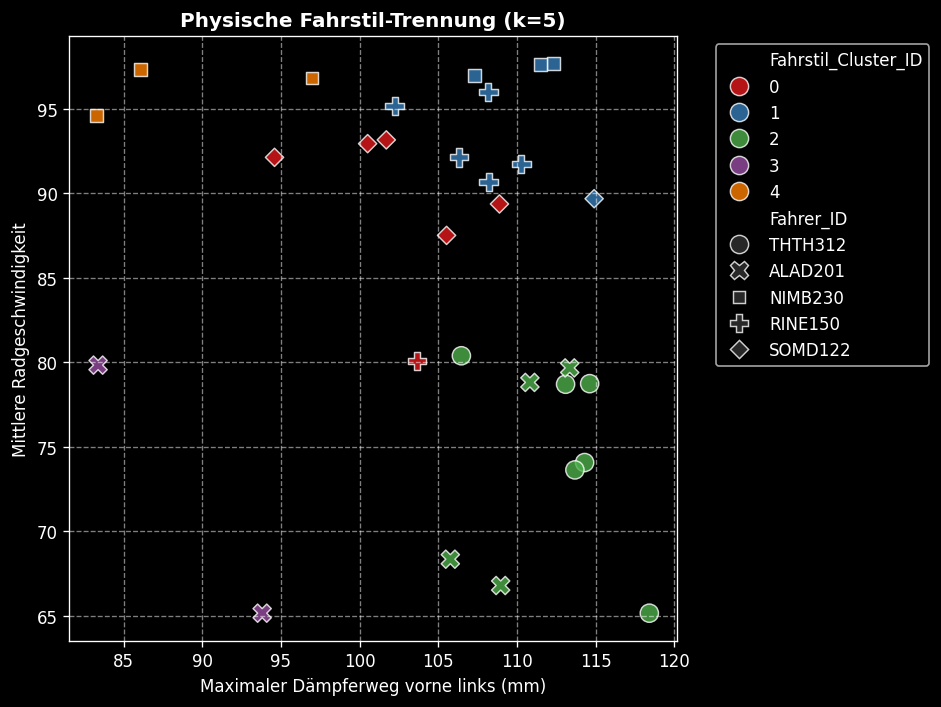

In [91]:
try: 
    x_clustering = df_master_ml.drop(columns=['Fahrer_ID', 'Segment_Nummer'])

    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_clustering)

    # auto group findings
    best_k = 2
    best_score = -1
    
    for k in range(2, 9):
        kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_test = kmeans_test.fit_predict(x_scaled)
        score = silhouette_score(x_scaled, labels_test)
        
        if score > best_score:
            best_score = score
            best_k = k

    kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    df_master_ml['Fahrstil_Cluster_ID'] = kmeans_final.fit_predict(x_scaled)

    # majority voting
    cluster_to_driver = {}
    
    for cluster_id in range(best_k):
        cluster_daten = df_master_ml[df_master_ml['Fahrstil_Cluster_ID'] == cluster_id]
        
        if not cluster_daten.empty:
            dominant_driver = cluster_daten['Fahrer_ID'].mode()[0]
            cluster_to_driver[cluster_id] = dominant_driver
        else:
            cluster_to_driver[cluster_id] = "Unbekannt"
            
    for c_id, fahrer in cluster_to_driver.items():
        print(f" -> Cluster {c_id} wird offiziell erkannt als: {fahrer}")
        
    df_master_ml['Vorhergesagter_Fahrer'] = df_master_ml['Fahrstil_Cluster_ID'].map(cluster_to_driver)

    fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

    # scatterplot
    sns.scatterplot(
        data=df_master_ml,
        x='s_damperFL_max',
        y='v_tyreFL_mean',
        hue='Fahrstil_Cluster_ID',
        style='Fahrer_ID',
        palette='Set1',
        s=120,
        alpha=0.8,
    )
    ax.set_title(f"Physische Fahrstil-Trennung (k={best_k})", fontweight='bold')
    ax.set_xlabel("Maximaler Dämpferweg vorne links (mm)")
    ax.set_ylabel("Mittlere Radgeschwindigkeit")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n[FAIL] Kritischer Fehler in der AI-Sektion: {e}")
    print("Bitte alleinerziehende Businesswoman um Hilfe bei der Fehlersuche. 💼")

[Daten] Training: 24 Runden | Echte Klausur: 6 Runden

 Ergebnis der Klausur ---
              precision    recall  f1-score   support

     ALAD201       0.00      0.00      0.00         1
     NIMB230       0.00      0.00      0.00         1
     RINE150       0.50      1.00      0.67         1
     SOMD122       1.00      1.00      1.00         2
     THTH312       0.50      1.00      0.67         1

    accuracy                           0.67         6
   macro avg       0.40      0.60      0.47         6
weighted avg       0.50      0.67      0.56         6



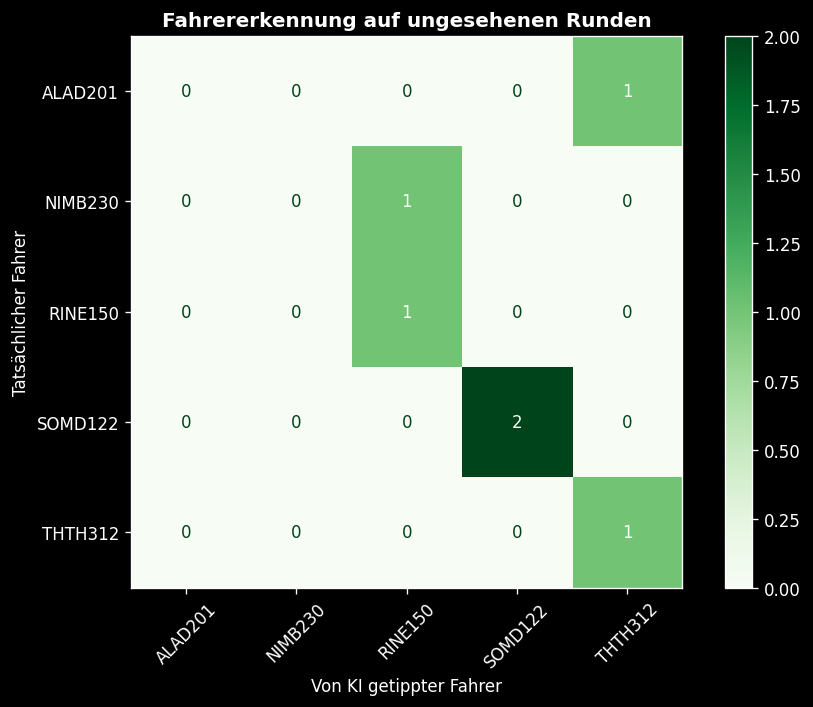

In [92]:
try:
    train_df, test_df = train_test_split(
        df_master_ml, test_size=0.2, random_state=42, stratify=df_master_ml['Fahrer_ID']
    )
    
    print(f"[Daten] Training: {len(train_df)} Runden | Echte Klausur: {len(test_df)} Runden")

    # Datenentfernung
    spalten_zum_loeschen = [
        'Fahrer_ID', 
        'Segment_Nummer', 
        'Fahrstil_Cluster_ID', 
        'Vorhergesagter_Fahrer',
        'Vorhergesagter_Cluster',
        'Erkannter_Fahrer'
    ]
    
    X_train = train_df.drop(columns=spalten_zum_loeschen, errors='ignore')
    X_test = test_df.drop(columns=spalten_zum_loeschen, errors='ignore')

    # Skalieren
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test) 

    # Training
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    train_df['Fahrstil_Cluster_ID'] = kmeans.fit_predict(X_train_scaled)

    # majority voting
    cluster_zu_fahrer = {}
    for cluster_id in range(5):
        cluster_daten = train_df[train_df['Fahrstil_Cluster_ID'] == cluster_id]
        if not cluster_daten.empty:
            cluster_zu_fahrer[cluster_id] = cluster_daten['Fahrer_ID'].mode()[0]
        else:
            cluster_zu_fahrer[cluster_id] = "Unbekannt"

    test_df['Vorhergesagter_Cluster'] = kmeans.predict(X_test_scaled)
    test_df['Erkannter_Fahrer'] = test_df['Vorhergesagter_Cluster'].map(cluster_zu_fahrer)

    y_true_test = test_df['Fahrer_ID']
    y_pred_test = test_df['Erkannter_Fahrer']
    
    print("\n Ergebnis der Klausur ---")
    print(classification_report(y_true_test, y_pred_test, zero_division=0))

    cm = confusion_matrix(y_true_test, y_pred_test)
    labels = sorted(y_true_test.unique())
    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap=plt.cm.Greens, xticks_rotation=45)
    
    plt.title("Fahrererkennung auf ungesehenen Runden", fontweight='bold')
    plt.xlabel("Von KI getippter Fahrer")
    plt.ylabel("Tatsächlicher Fahrer")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n[FAIL] Kritischer Fehler im Test-Modul: {e}")

[KI] Trainiere k-Means im dreidimensionalen Raum...

--- ERGEBNIS DER 3D-KLAUSUR ---
              precision    recall  f1-score   support

     ALAD201       0.00      0.00      0.00         1
     NIMB230       0.00      0.00      0.00         1
     RINE150       0.50      1.00      0.67         1
     SOMD122       1.00      1.00      1.00         2
     THTH312       0.50      1.00      0.67         1

    accuracy                           0.67         6
   macro avg       0.40      0.60      0.47         6
weighted avg       0.50      0.67      0.56         6



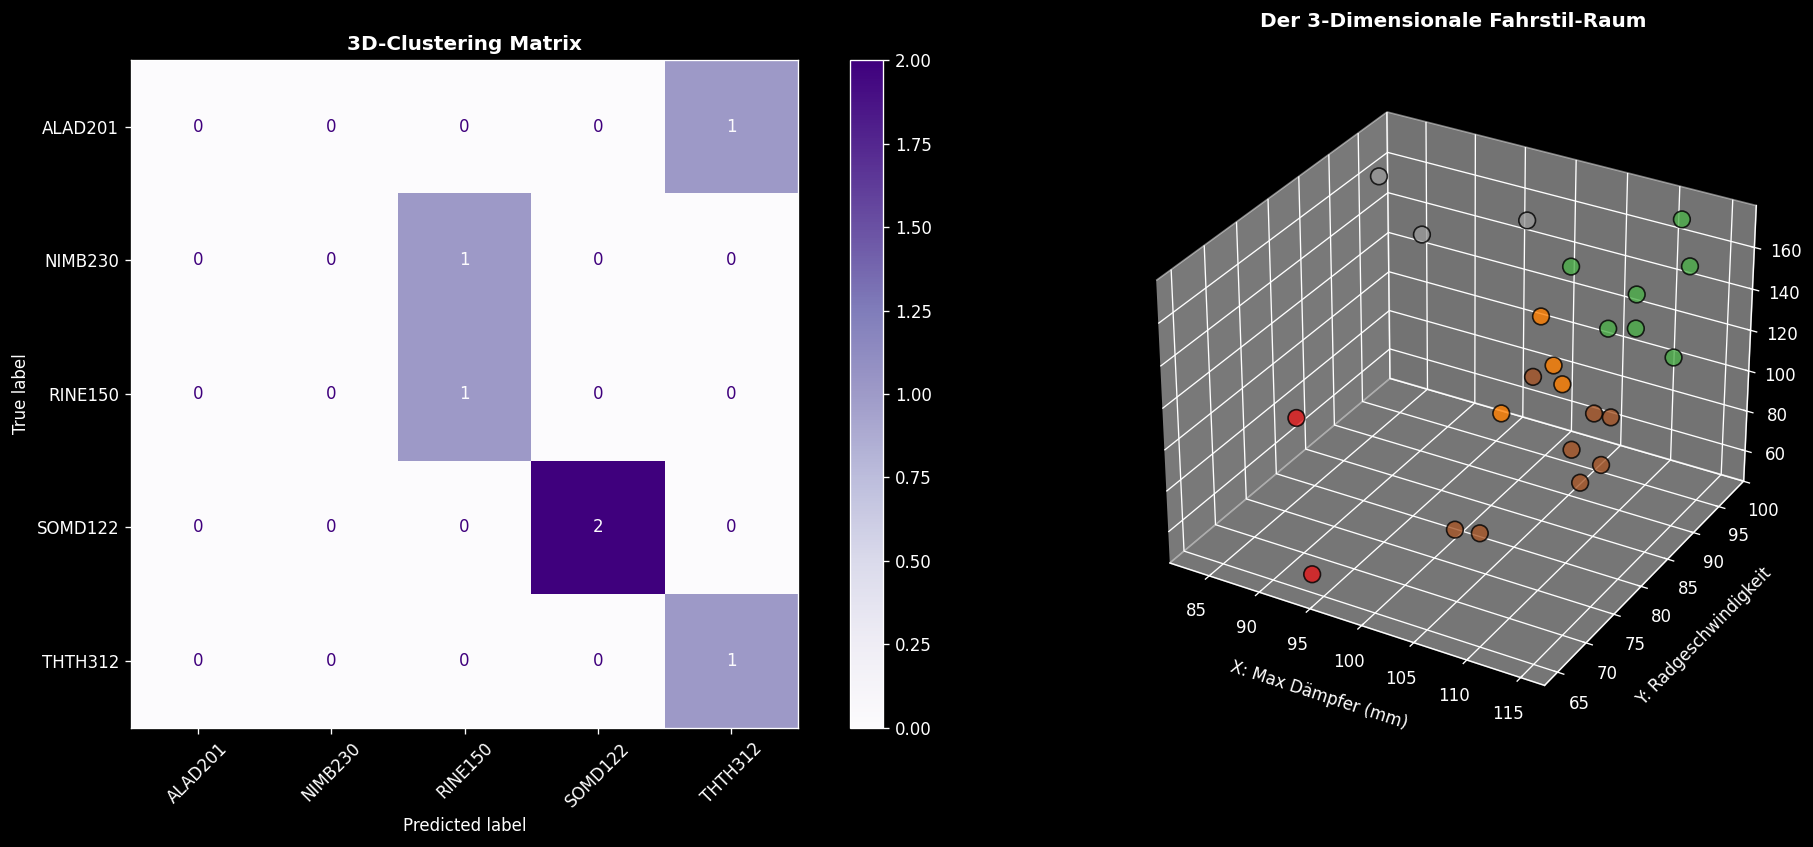

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

try:
    # 1. DER 80/20 SPLIT
    train_df, test_df = train_test_split(
        df_master_ml, test_size=0.2, random_state=42, stratify=df_master_ml['Fahrer_ID']
    )
    
    # 2. DIE 3 DIMENSIONEN (X, Y und Z) AUSWÄHLEN
    features_3d = ['s_damperFL_max', 'v_tyreFL_mean', 's_damperFL_var']
    
    X_train_3d = train_df[features_3d]
    X_test_3d = test_df[features_3d]

    # 3. SKALIEREN (Der Raum muss perfekt quadratisch sein)
    scaler_3d = StandardScaler()
    X_train_scaled = scaler_3d.fit_transform(X_train_3d)
    X_test_scaled = scaler_3d.transform(X_test_3d) 

    # 4. KI TRAINIEREN IM 3D-RAUM
    print("[KI] Trainiere k-Means im dreidimensionalen Raum...")
    kmeans_3d = KMeans(n_clusters=5, random_state=42, n_init=10)
    train_df['Cluster_3D'] = kmeans_3d.fit_predict(X_train_scaled)

    # 5. MAJORITY VOTING (Fahrer-Namensschilder kleben)
    cluster_zu_fahrer_3d = {}
    for cluster_id in range(5):
        cluster_daten = train_df[train_df['Cluster_3D'] == cluster_id]
        if not cluster_daten.empty:
            cluster_zu_fahrer_3d[cluster_id] = cluster_daten['Fahrer_ID'].mode()[0]
        else:
            cluster_zu_fahrer_3d[cluster_id] = "Unbekannt"

    # 6. DIE KLAUSUR SCHREIBEN
    test_df['Vorhergesagter_Cluster'] = kmeans_3d.predict(X_test_scaled)
    test_df['Erkannter_Fahrer_3D'] = test_df['Vorhergesagter_Cluster'].map(cluster_zu_fahrer_3d)

    # 7. AUSWERTUNG ZEICHNEN
    y_true_test = test_df['Fahrer_ID']
    y_pred_test = test_df['Erkannter_Fahrer_3D']
    
    print("\n--- ERGEBNIS DER 3D-KLAUSUR ---")
    print(classification_report(y_true_test, y_pred_test, zero_division=0))

    # Die Visualisierung: Matrix und 3D-Würfel nebeneinander
    fig = plt.figure(figsize=(18, 7), dpi=120)
    
    # Links: Matrix
    ax1 = fig.add_subplot(121)
    cm = confusion_matrix(y_true_test, y_pred_test)
    labels = sorted(y_true_test.unique())
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax1, cmap=plt.cm.Purples, xticks_rotation=45)
    ax1.set_title("3D-Clustering Matrix", fontweight='bold')
    
    # Rechts: Echter 3D-Plot
    ax2 = fig.add_subplot(122, projection='3d')
    
    # Punkte in den 3D Raum werfen
    scatter = ax2.scatter(
        train_df['s_damperFL_max'], 
        train_df['v_tyreFL_mean'], 
        train_df['s_damperFL_var'],
        c=train_df['Cluster_3D'], 
        cmap='Set1', 
        s=100, 
        edgecolor='k',
        alpha=0.8
    )
    
    ax2.set_title("Der 3-Dimensionale Fahrstil-Raum", fontweight='bold', pad=20)
    ax2.set_xlabel("X: Max Dämpfer (mm)", labelpad=10)
    ax2.set_ylabel("Y: Radgeschwindigkeit", labelpad=10)
    ax2.set_zlabel("Z: Dämpfer-Varianz", labelpad=10)
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n[FAIL] Fehler im 3D-Modul: {e}")